# Figure diagnosing block size

Maps as before, but of std / mean of trigger threshold across block sizes, with insets showing a couple of key locations (areas of most / least variation by block size perhaps? even better if we can stick the inset axis in the oceans?)

In [14]:
import xarray as xr
from xarray.groupers import SeasonResampler
import xesmf as xe
import numpy as np
import pandas as pd 
import geopandas as gpd
import os
import glob
import re
import string
from matplotlib import pyplot as plt
from matplotlib import patches as mpatches
import matplotlib as mpl
from cartopy import crs as ccrs
import cmocean
from dask.diagnostics import ProgressBar
from tqdm.notebook import tqdm
from numba import jit as njit
from distributed import Client

from funcs_support import get_params,get_filepaths, utility_print, utility_save, load_data, area_mean
from funcs_aux import get_landmask

dir_list = get_params()

mpl.font_manager.fontManager.addfont(dir_list['aux'] + "fonts/Lato-Regular.ttf")
mpl.font_manager.fontManager.addfont(dir_list['aux'] + "fonts/Lato-Bold.ttf")

mpl.rcParams.update({
    "font.family": "Lato",
})

subplot_lettering = string.ascii_lowercase #string.ascii_lowercase

In [2]:
# Trigger threshold
aa_trigger = 0.2
# Random seed for bootstraps
rng = np.random.default_rng()
# How many years / block
samp_sizes = np.arange(1,20)
# How many bootstrap draws
ndraws = 1000

# Set up filepaths
df = get_filepaths()

# Variables / bootstrap dimension setup
boot_dim = 'year'
var = 'pr'

# Which data to use
# GPCP, CHIRPS, or NCEP-CFSv2 / NCEP-CFSv2-ensmean
proc_source = 'NCEP-CFSv2-ensmean' 
#proc_source = 'GPCP'

# Set output filenames
load_fns = {'threshs':dir_list['tmp']+'pr-trigger-threshs_year_'+proc_source+'.zarr',
              'seasmask':dir_list['aux']+'seasmask_CHIRPS.zarr'}

In [3]:
threshs = xr.open_zarr(load_fns['threshs'])

In [5]:
blocksize_dependence = xr.merge([(threshs.threshmean.std('block_nyears') / threshs.threshmean.mean('block_nyears')).load().to_dataset(name='mean_dep'),
                                 (threshs.triggthresh.std('draw').std('block_nyears') / threshs.triggthresh.std('draw').mean('block_nyears')).load().to_dataset(name='std_dep'),
                                 (threshs.triggrange_cv.std('block_nyears') / threshs.triggrange_cv.mean('block_nyears')).load().to_dataset(name='range_dep'),
                                 (threshs.triggrange_cv.sel(block_nyears=slice(3,None)).std('block_nyears') / threshs.triggrange_cv.sel(block_nyears=slice(3,None)).mean('block_nyears')).load().to_dataset(name='range3plus_dep'),
                                 (threshs.triggrange_cv.sel(block_nyears=slice(5,None)).std('block_nyears') / threshs.triggrange_cv.sel(block_nyears=slice(5,None)).mean('block_nyears')).load().to_dataset(name='range5plus_dep'),
                                 (threshs.triggrange_cv.sel(block_nyears=slice(2,7)).std('block_nyears') / threshs.triggrange_cv.sel(block_nyears=slice(2,7)).mean('block_nyears')).load().to_dataset(name='range2to7_dep')])



/tmp/ipykernel_12331/1534474185.py:1: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  blocksize_dependence = xr.merge([(threshs.threshmean.std('block_nyears') / threshs.threshmean.mean('block_nyears')).load().to_dataset(name='mean_dep'),
/tmp/ipykernel_12331/1534474185.py:1: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  blocksize_depend

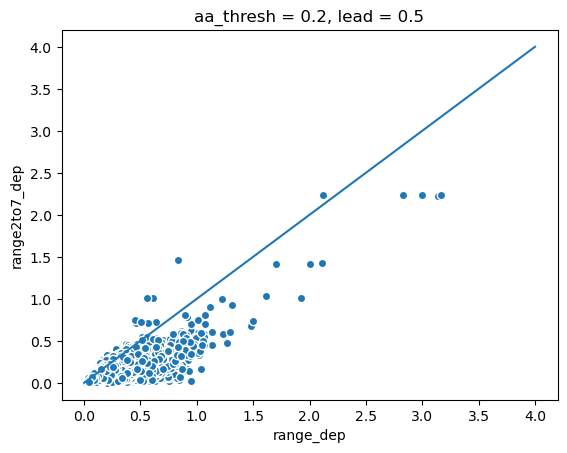

In [6]:
ax = plt.subplot()
blocksize_dependence.plot.scatter(x='range_dep',
                                  y = 'range2to7_dep')
                                  #y='range5plus_dep')
ax.plot([0,4],[0,4])

In [7]:
# Get landmask
landmask = get_landmask(threshs,lm_source='ne110')

# Get country borders
gdf = gpd.read_file(dir_list['aux']+'geo_data/ne_10m_admin_0_countries_iso/ne_10m_admin_0_countries_iso.shp')

# Get mask for if there's an active season locally
active_seasons = xr.open_zarr(load_fns['seasmask'])
# Regrid seasonmask to trigger threshold grid
rgrd = xe.Regridder(active_seasons,threshs,'conservative')
active_seasons_rg = rgrd(active_seasons)
active_seasons_rg = active_seasons_rg.sel(lat=threshs.lat.values)

lat/lon bounds not found in dataset; they will be created.


In [8]:
#-------------------------------------
# Get threshold-based dry season mask
#-------------------------------------
seas_thresh = 0.5 # mm/day

# Load data
dsm = load_data(proc_source,data='seasavg')

# Get boolean mask for threshold exceedence
dry_thresh = dsm.pr.mean('year')>seas_thresh



/home/kschwarz/projects/forecast_uncertainty/2. figures/blocksize_dependence_range2to7.pdf saved!
/home/kschwarz/projects/forecast_uncertainty/2. figures/blocksize_dependence_range2to7.png saved!


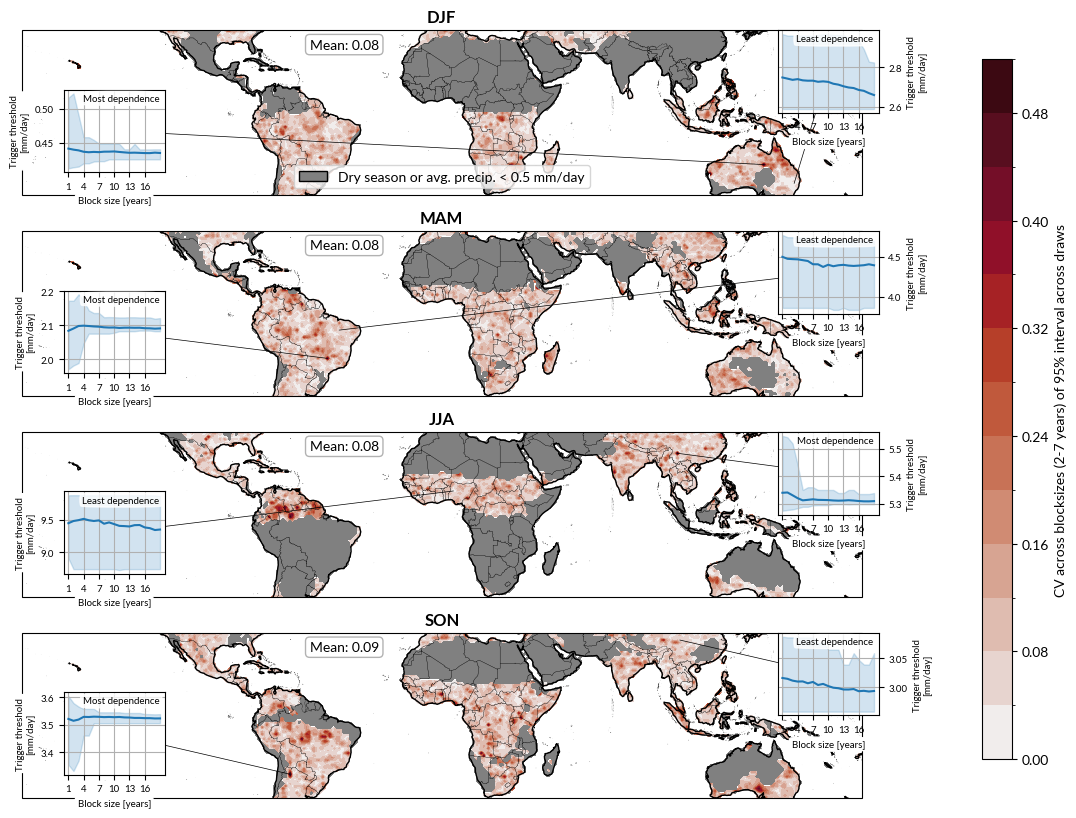

In [18]:
subset_params = {'lat':slice(-35,35),'lon':slice(-180,180)}

cbar_params = {'mean_dep':{'vmin':0,'vmax':0.07,'cmap':cmocean.cm.amp,'levels':8},
               'range_dep':{'vmin':0,'vmax':0.5,'cmap':cmocean.cm.amp,'levels':13},
               'range3plus_dep':{'vmin':0,'vmax':0.5,'cmap':cmocean.cm.amp,'levels':13},
               'range5plus_dep':{'vmin':0,'vmax':0.5,'cmap':cmocean.cm.amp,'levels':13},
               'range2to7_dep':{'vmin':0,'vmax':0.5,'cmap':cmocean.cm.amp,'levels':13}}
cbar_label = {'mean_dep':'CV across blocksizes of trigger threshold',
              'range_dep':'CV across blocksizes of 95% interval across draws',
              'range3plus_dep':'CV across blocksizes (>= 3 years) of 95% interval across draws',
              'range5plus_dep':'CV across blocksizes (>= 5 years) of 95% interval across draws',
              'range2to7_dep':'CV across blocksizes (2-7 years) of 95% interval across draws'}

inset_label = {'mean_dep':'Trigger threshold\n[mm/day]',
               'range_dep':'Trigger threshold\n[mm/day]',
               'range3plus_dep':'Trigger threshold\n[mm/day]',
               'range5plus_dep':'Trigger threshold\n[mm/day]',
               'range2to7_dep':'Trigger threshold\n[mm/day]'}

output_fns = {'mean_dep':f'{dir_list['figs']}blocksize_dependence_mean',
              'range_dep':f'{dir_list['figs']}blocksize_dependene_range',
              'range3plus_dep':f'{dir_list['figs']}blocksize_dependence_range3plus',
              'range5plus_dep':f'{dir_list['figs']}blocksize_dependence_range5plus',
              'range2to7_dep':f'{dir_list['figs']}blocksize_dependence_range2to7'}
save_fig = True

for var in ['range2to7_dep']:#['range5plus_dep']:
    fig = plt.figure(figsize=(12,10))
    
    for seas_idx,seas in enumerate(['DJF','MAM','JJA','SON']):
        ax = plt.subplot(4,1,seas_idx+1,projection=ccrs.PlateCarree())
    
        # Get data
        plot_data = blocksize_dependence[var].sel(season=seas,**subset_params)
    
        # Subset data to land / relevant season only
        season_mask = (active_seasons_rg.seasmask.sel(season=seas,**subset_params) & 
                       dry_thresh.sel(season=seas)).where(landmask).load()
        season_mask = season_mask.where(~np.isnan(season_mask),0).astype(bool)
        plot_data = plot_data.where(season_mask)
    
        # Plot
        plot_data.plot.contourf(transform=ccrs.PlateCarree(),**cbar_params[var],
                                add_colorbar=False)
    
        # Grey out regions without an active rainy season or that are generally 
        # too dry
        season_mask.where(landmask).plot.contourf(levels=[-0.5, 0.5, 1.5],
                                     colors=['grey','none'],
                                     hatches=[None, None],
                                     transform=ccrs.PlateCarree(),
                                     add_colorbar=False)
    
    
        # Get sample locations for inset
        all_locs = plot_data.stack(locv=['lat','lon']).locv
        plot_locs = {'max':all_locs[plot_data.stack(locv = ['lat','lon']).argmax('locv')],
                     'min':all_locs[plot_data.stack(locv=['lat','lon']).argmin('locv')]}
    
        ax.coastlines()
        ax.set_title(seas,fontweight='bold',fontsize=12)
        
        # Country borders
        # Add to plot (subset_params in slice format)
        gdf.cx[subset_params['lon'],subset_params['lat']].plot(ax=ax,facecolor='none',edgecolor='k',
                                                           linestyle='-',linewidth=0.15,
                                                           transform=ccrs.PlateCarree())
        ax.set_extent([subset_params['lon'].start,
                       subset_params['lon'].stop,
                       subset_params['lat'].start,
                       subset_params['lat'].stop])
    
        if seas_idx == 0:
            ax.legend(handles=[mpatches.Patch(facecolor='grey',edgecolor='k',
                                              label=f'Dry season or avg. precip. < {str(seas_thresh)} mm/day')],loc='lower center')


        # Plot mean text
        ax.annotate(f'Mean: {str(np.round(area_mean(plot_data.where(season_mask.where(landmask))).values,2))}',
                    (0.425,0.95),
                    xycoords = 'axes fraction',
                    ha='right',va='top',
                    bbox={'boxstyle':'round','alpha':0.3,
                          'fc':'w'})
    
        #---------------------------------
        # Inset axes
        #---------------------------------
        # Rectangle dimensions
        rects = {'pac':[0.05, 0.14, 0.12, 0.5],
                 'ind':[0.9, 0.5, 0.12, 0.5]}
        
        # Ref points to calculate which is closer
        ref_points = {'pac':(-160,0),
                      'ind':(80,-10)}
    
        typ_labels = {'min':'Least dependence',
                  'max':'Most dependence'}
    
        
        for inset_typ in rects:
        
            # Simple distance (since we actually want -180 to be 360, not 0 away 
            # from 180 for plotting purposes)
            dist_to_insets = {typ:np.sqrt((plot_locs[typ].lon - ref_points[inset_typ][0])**2 + 
                    (plot_locs[typ].lat - ref_points[inset_typ][1])**2).values
             for typ in plot_locs}
        
            # Get key of min distance
            plot_typ = min(dist_to_insets,key=dist_to_insets.get)
            # Pop that one so it doesn't get chosen again above
            plot_loc = plot_locs.pop(plot_typ)
            
            # Get data needed
            inset_data = threshs.sel(lat=plot_loc.lat.values,lon=plot_loc.lon.values)
            
            # Create inset axis
            ax_inset = ax.inset_axes(rects[inset_typ])
            
            # Plot threshold evolution by block size
            inset_data.sel(season=seas).threshmean.plot(ax=ax_inset)
            ax_inset.fill_between(inset_data.block_nyears,
                            inset_data.sel(season=seas).triggthresh.quantile(0.025,dim='draw'),
                            inset_data.sel(season=seas).triggthresh.quantile(0.975,dim='draw'),
                            color='tab:blue',alpha=0.2)
    
            ax_inset.set_title('')
            ax_inset.annotate(typ_labels[plot_typ],(0.95,0.95),
                              xycoords = 'axes fraction',
                              bbox = {'boxstyle':'round4','alpha':0.8,'fc':'w','ec':'w'},fontsize=7,
                              ha='right',va='top')
            axlabel_bbox = {'fc':'w','ec':'w','boxstyle':'round4'}
            ax_inset.set_xticks(np.arange(1,inset_data.block_nyears.max(),3))
            ax_inset.set_xlabel('Block size [years]',bbox=axlabel_bbox,fontsize=7)
            ax_inset.set_ylabel(inset_label[var],bbox=axlabel_bbox,fontsize=7)
            ax_inset.grid()
            ax_inset.tick_params(axis='both', which='major', labelsize=7)
            if inset_typ == 'ind':
                ax_inset.yaxis.set_label_position("right")
                ax_inset.yaxis.tick_right()
    
            
            # Add connection to location
            con=mpl.patches.ConnectionPatch(
                xyA=(plot_loc.lon.values, plot_loc.lat.values),
                coordsA=ccrs.PlateCarree()._as_mpl_transform(ax),
                xyB=(0.5,0.5),coordsB=ax_inset.transAxes,
                color='k',lw=0.5,zorder=1
            )
            ax.add_artist(con)

    
    
    fig.subplots_adjust(right=0.825)
    cax = fig.add_axes([0.925, 0.15, 0.025, 0.7])
    levels = mpl.ticker.MaxNLocator(nbins=cbar_params[var]['levels']).tick_values(cbar_params[var]['vmin'],cbar_params[var]['vmax'])
    norm = mpl.colors.BoundaryNorm(levels, ncolors=cbar_params[var]['cmap'].N, clip=True)
    sm = plt.cm.ScalarMappable(cmap=cbar_params[var]['cmap'],norm=norm)
    plt.colorbar(sm,cax=cax,label=cbar_label[var])

    if save_fig:
        utility_print(output_fns[var])


## Helper functions to be put in a separate .py file

In [20]:
chunk_sizes = {'NCEP-CFSv2':20,
               'NCEP-CFSv2-ensmean':40,
               'GPCP':40,
               'CHIRPS':200}



@njit
def get_boot_threshs(ts, start_years, samp_size, aa_trigger=aa_trigger):
    ''' numbaized block bootstrap quantile calculation code ''' 
    n_run, n_block = start_years.shape

    # Create empty 
    if ts.ndim==1:
        out = np.empty(n_run,dtype=ts.dtype)
    else:
        out = np.empty((ts.shape[1],n_run),dtype=ts.dtype)
    
    # Process by run
    if not np.all(np.isnan(ts)):
        for run_idx in range(n_run):
            if ts.ndim == 1:
                draws = np.empty((n_block, samp_size), dtype=ts.dtype)
                for b in range(n_block):
                    sy = start_years[run_idx, b]
                    draws[b, :] = ts[sy:sy + samp_size]
                # Ensure final time series is same length as original, without overhangs
                draws = draws.flatten()[0:ts.shape[0]]
                out[run_idx] = np.quantile(draws, aa_trigger)
            
            else:
                for idv_idx in range(ts.shape[1]):
                    draws = np.empty((n_block, samp_size), dtype=ts.dtype)
                    for b in range(n_block):
                        sy = start_years[run_idx, b]
                        draws[b, :] = ts[sy:sy + samp_size,idv_idx]
                    draws = draws.flatten()[0:ts.shape[0]]
                    out[idv_idx,run_idx] = np.quantile(draws, aa_trigger)
    else:
        out = out*np.nan

    return out

def boot_threshs_block(ds,samp_size,var='pr',boot_dim = 'year',
                       aa_trigger = aa_trigger):
    ''' quantile calculation of block bootstrap samples, optimized for xr.map_blocks() 

    Parameters
    ---------------
    ds : xr.Dataset
        Dataset containing both `var` (below) _and_ 
        `start_years`, a `draw` x `block` datarray
        giving the indices of the start years of 
        each bootstrap block

    var : str, by default 'pr'
        The variable in `ds` to process

    boot_dim : str, by default 'year'
        The dimension of `var` across which to bootstrap

    aa_trigger : float
        The quantile to calculate (e.g., 0.2)

    samp_size : int
        The bootstrap block size (e.g., 5)

    Returns
    ---------------
    threshs : xr.DataArray
        The quantiles 
    
    
    '''
    #print(
    #    "BLOCK SHAPES:",
    #    {k: v.shape for k, v in ds.data_vars.items()},
    #    flush=True,
    #)
    # Transpose main variable ensure correct orders for numba / 
    # raw numpy below
    main_dim_order = ['lat','lon',boot_dim]
    other_dims = [dim for dim in ds[var].dims if dim not in main_dim_order]
    ds[var] = ds[var].transpose(*main_dim_order,*other_dims)

    #print('1. '+str(ds.sizes))

    # Stack dimensions that aren't lat, lon, and the 
    # dimension to bootstrap over, to make np.quantile
    # work in numba (the axis argument isn't supported)
    if len(other_dims)>1:
        ds = ds.stack(idv = other_dims)
        stacked = True
    else:
        stacked = False
    #print('2. '+str(ds.sizes))
        
    # Transpose start years to ensure correct orders
    # for numba / raw numpy below
    ds['start_years'] = ds['start_years'].transpose('draw','block')

    # Create empty array for output
    if len(other_dims)==0:
        threshs = np.empty((ds.sizes['lat'], ds.sizes['lon'], ds.sizes['draw']), dtype=ds[var].dtype)
    else:
        # (flexible, since it's only "idv" in the case of more than one "other_dim",
        # otherwise, it's the original name of that dimension)
        odim_name = [dim for dim in ds[var].dims if dim not in main_dim_order][0]
        threshs = np.empty((ds.sizes['lat'],ds.sizes['lon'],ds.sizes[odim_name],ds.sizes['draw']),
                       dtype=ds[var].dtype)

    # Run block bootstrap threshold calculation
    for i in range(ds.sizes['lat']):
        for j in range(ds.sizes['lon']):
            ts = ds[var].isel(lat=i,lon=j).values

            threshs[i,j,:] = get_boot_threshs(ts,ds.start_years.values,samp_size)

    # Assign to ds to allow unstacking, if necessary
    if len(other_dims) == 0:
        ds['threshs'] = (('lat','lon','draw'),threshs)
    else:
        ds['threshs'] = (('lat','lon',odim_name,'draw'),threshs)

    # Unstack, if necessary
    if stacked:
        out_da = ds['threshs'].unstack()
    else:
        out_da = ds['threshs']

    out_da = out_da.transpose('lat','lon',*other_dims,'draw')

    #print(
    #    "OUTPUT SIZES:",
    #    out_da.sizes,
    #    flush=True,
    #)

    
    return out_da